In [1]:
%pip install "numpy" "opencv-python" -q
%pip install git+https://www.github.com/mouseland/cellpose.git
%pip install pyocclient -q

  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-koduny8l
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-koduny8l
  Resolved https://www.github.com/mouseland/cellpose.git to commit a9f8bfcde43033247309e3982747df9fe9f09315
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 129.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 60.2 MB/s eta 0:00:00:00:0100:01
  Created wheel for cellpose: filename=cellpose-4.1.1-py3-none-any.whl size=213288 sha256=69703e83a755f8d5c1f0886e92505908ba88be9e861b0984599f20926f5a3db1
  Stored in directory: /tmp/pip-ephem-wheel-cache-z5n_if3d/wheels/df/b6/31/a3013c44290eabb46f4c06d1efb19744124fcad2d59684ec5e
Successfully built cellpose
  Preparing metadata (setup.py) ... done


In [2]:
import owncloud, getpass, cellpose

# Config
url, user = 'https://cloud.minesparis.psl.eu', 'gabriel.gautier'
oc_session = owncloud.Client(url)
oc_session.login(user, getpass.getpass(f"PW {user}: "))
oc_session.get_file('/travail/Mines/DIMA/Segmentation/scripts/tool.py', 'tool.py')

import tool
oc = tool.Owncloud(oc_session)

print("Tool chargé et prêt.")

Tool chargé et prêt.


In [3]:
!nvcc --version
!nvidia-smi

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


Tue Mar 31 13:29:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   44C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
oc.upload_data()

In [4]:
import os, shutil
import numpy as np
import matplotlib.pyplot as plt
import cv2


from cellpose import core, utils, io, models, metrics, train, dynamics, transforms, plot
from glob import glob

import importlib
importlib.reload(tool)
import tool

visualizer = tool.CellVisualizer()

In [9]:
oc.upload_scripts()
oc.upload_models()

In [6]:
use_GPU = core.use_gpu()
yn = ['NO', 'YES']
print(f'>>> GPU activated? {yn[use_GPU]}')

>>> GPU activated? YES


In [ ]:

io.logger_setup()

model = models.CellposeModel(gpu=True)

path = '001'
img = visualizer.load_data(path, mode='Image')

masks_pred, flows, styles = model.eval(img, niter=1000)


output_dir = './data/prediction/cellpose4/'
os.makedirs(output_dir, exist_ok=True)

filename = os.path.basename(path)
name_without_ext = os.path.splitext(filename)[0]
save_path = os.path.join(output_dir, f"{name_without_ext}_Cell_pred.bmp")

cv2.imwrite(save_path, masks_pred)

print(f"Masque sauvegardé : {save_path}")

2026-03-20 10:58:34,385 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-20 10:58:34,388 [INFO] 
cellpose version: 	4.0.10.dev21+g849ca11f1 
platform:       	linux 
python version: 	3.12.12 
torch version:  	2.10.0+cu128
2026-03-20 10:58:34,389 [INFO] ** TORCH CUDA version installed and working. **
2026-03-20 10:58:34,390 [INFO] >>>> using GPU (CUDA)
2026-03-20 10:58:36,678 [INFO] >>>> loading model /root/.cellpose/models/cpsam
Masque sauvegardé : ./data/prediction/cellpose4/001_Cell_pred.bmp


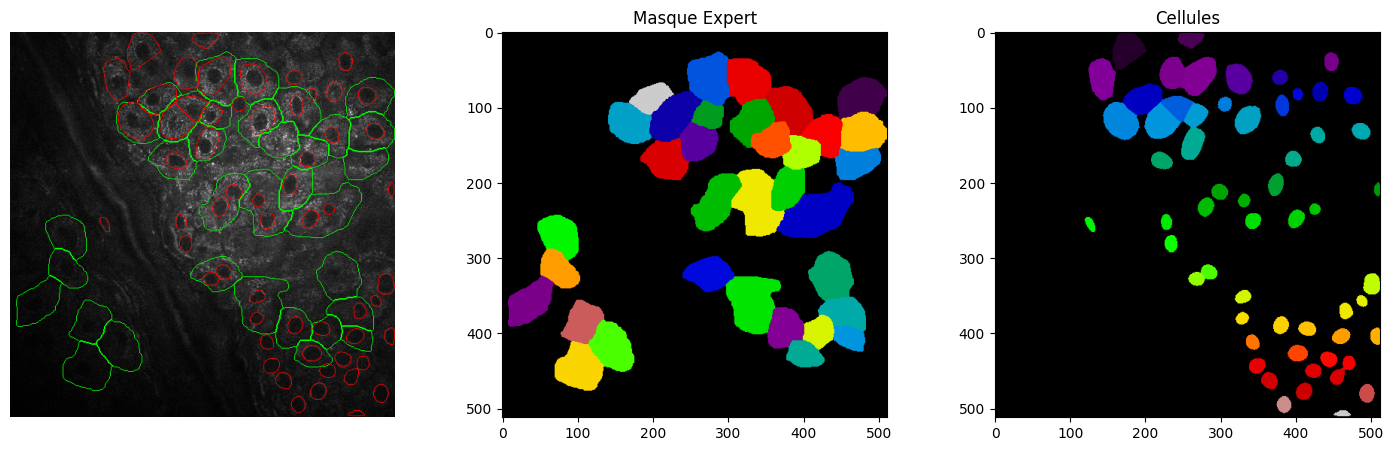

[Cellpose4] F1: 0.087 | TP: 4 | FN: 30


{'f1': 0.08695652335882187,
 'ap': 0.04545454680919647,
 'tp': 4,
 'fp': 54,
 'fn': 30}

In [ ]:
true_mask = visualizer.load_data("001", mode='Cell')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
visualizer.plot_overlay(i = "001", mask_pred=masks_pred, ax=ax1, show=False)
visualizer.plot(data = masks_pred, mode = 'Cell_pred', ax=ax3, show=False)
visualizer.plot(i = "001", mode='Cell', ax=ax2, show=False, title="Masque Expert")
plt.show()


ev = tool.Stats()
ev.report("Cellpose4", true_mask, masks_pred)


In [8]:

import random


my_ids = ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010','011', '012', '013', '014', '015', '016', '017', '018', '019', '020','021', '022', '023', '024', '025', '026', '027', '028', '029', '030','031', '032', '033', '034', '035', '036', '037', '038', '039', '040','041', '042', '043', '044', '045', '046', '047', '048', '049', '050'] 


random.seed(42)
random.shuffle(my_ids)

n = len(my_ids)
ids_train = my_ids[:int(0.7 * n)]
ids_val   = my_ids[int(0.7 * n):int(0.8 * n)]
ids_test  = my_ids[int(0.8 * n):]

print(f"Split : Train({len(ids_train)}) | Val({len(ids_val)}) | Test({len(ids_test)})")



Split : Train(35) | Val(5) | Test(10)


2026-03-31 14:04:26,077 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-31 14:04:26,078 [INFO] 
cellpose version: 	4.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
--- Test LR = 5e-05 ---
2026-03-31 14:04:26,098 [WARNING] model_type argument is not used in v4.0.1+. Ignoring this argument...
2026-03-31 14:04:26,100 [INFO] ** TORCH CUDA version installed and working. **
2026-03-31 14:04:26,100 [INFO] >>>> using GPU (CUDA)
2026-03-31 14:04:28,061 [INFO] >>>> loading model /root/.cellpose/models/cpsam
2026-03-31 14:04:28,629 [INFO] >>> converting bfloat16 network to float32 for training
2026-03-31 14:04:28,638 [INFO] computing flows for labels


100%|██████████| 35/35 [00:03<00:00,  9.81it/s]

2026-03-31 14:04:32,225 [INFO] computing flows for labels



100%|██████████| 5/5 [00:00<00:00,  9.91it/s]

2026-03-31 14:04:32,735 [INFO] >>> computing diameters


...


100%|██████████| 5/5 [00:00<00:00,  9.83it/s]

2026-03-31 14:14:04,557 [INFO] >>> computing diameters



100%|██████████| 5/5 [00:00<00:00, 778.19it/s]

2026-03-31 14:14:04,611 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-03-31 14:14:05,064 [INFO] >>> n_epochs=20, n_train=35, n_test=5
2026-03-31 14:14:05,064 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-03-31 14:14:05,066 [INFO] >>> saving model to models/test_lr_5e-06
2026-03-31 14:14:18,865 [INFO] 0, train_loss=4.1677, test_loss=3.9382, LR=0.000000, time 13.80s
2026-03-31 14:15:25,911 [INFO] 5, train_loss=2.8512, test_loss=2.2922, LR=0.000003, time 80.84s
2026-03-31 14:16:33,069 [INFO] 10, train_loss=2.0420, test_loss=2.0554, LR=0.000005, time 148.00s
2026-03-31 14:18:32,795 [INFO] saving network parameters to models/test_lr_5e-06
2026-03-31 14:18:41,926 [INFO] >>> converting network back to torch.bfloat16 after training
2026-03-31 14:18:41,946 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-03-31 14:18:42,685 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-03-31 14:18:43,366 

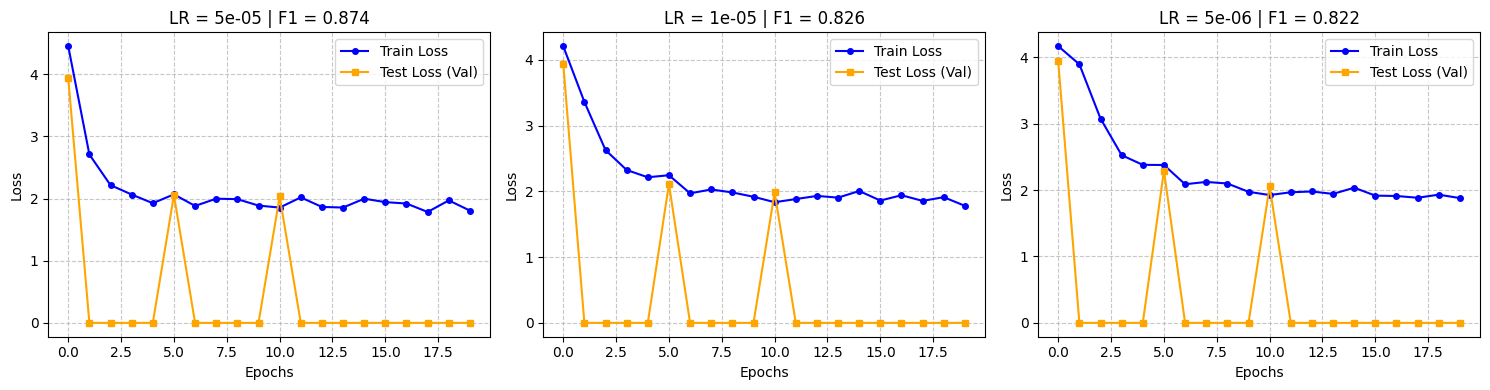

Summary
LR: 5e-05 -> F1-Score: 0.8740
LR: 1e-05 -> F1-Score: 0.8261
LR: 5e-06 -> F1-Score: 0.8221


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from cellpose import train, models, io
ev = tool.Stats()

X_train, Y_train = visualizer.load_channel(ids_train, mode= 'raw')
X_val, Y_val     = visualizer.load_channel(ids_val, mode = 'raw')

io.logger_setup()
learning_rates = [ 0.00005,0.00001,0.000005] 
fig, axes = plt.subplots(1, len(learning_rates), figsize=(15, 4))

resultats_lr = {}

for i, lr in enumerate(learning_rates):
    print(f"--- Test LR = {lr} ---")
    
    # Spécifiez le modèle de base exact ici
    model = models.CellposeModel(model_type='cpsam', gpu=True)
    
    # 1. Entraînement sur 20 époques
    m_path, t_loss, v_loss = train.train_seg(
        model.net,
        train_data=X_train, train_labels=Y_train,
        test_data=X_val, test_labels=Y_val,
        n_epochs=20,         
        learning_rate=lr,
        weight_decay=0.0001,
        save_path='.',
        model_name=f'test_lr_{lr}'
    )
    
    total_tp, total_fp, total_fn = 0, 0, 0
    
    for idx, img_val in enumerate(X_val):
        true_mask = Y_val[idx]

        mask_pred, _, _ = model.eval(img_val, resample=True, channels=[1, 2])
        
        perf = ev.summary_perf(true_mask, mask_pred, iou_threshold=0.5)
        total_tp += perf['tp']
        total_fp += perf['fp']
        total_fn += perf['fn']
        
    if (total_tp + total_fp + total_fn) > 0:
        precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
        recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    else:
        f1_score = 0.0
        
    resultats_lr[lr] = f1_score
    
    visualizer.plot_loss(t_loss, v_loss, title=f"LR = {lr} | F1 = {f1_score:.3f}", ax=axes[i], show=False)

plt.tight_layout()
plt.show()

# Affichage du résumé
print("Summary")
for lr, f1 in resultats_lr.items():
    print(f"LR: {lr} -> F1-Score: {f1:.4f}")

In [7]:
import json

with open('./data/dataset_splits.json', 'r') as f:
    splits = json.load(f)

ids_train = splits['train']
ids_val   = splits['val']
ids_test  = splits['test']

print(f"Splits chargés : Train({len(ids_train)}) | Val({len(ids_val)}) | Test({len(ids_test)})")

Splits chargés : Train(71) | Val(10) | Test(21)


2026-03-23 11:05:20,282 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-23 11:05:20,283 [INFO] 
cellpose version: 	4.0.10.dev21+g849ca11f1 
platform:       	linux 
python version: 	3.12.12 
torch version:  	2.10.0+cu128
2026-03-23 11:05:20,284 [INFO] ** TORCH CUDA version installed and working. **
2026-03-23 11:05:20,285 [INFO] >>>> using GPU (CUDA)
2026-03-23 11:05:22,407 [INFO] >>>> loading model /root/.cellpose/models/cpsam
2026-03-23 11:05:26,436 [INFO] >>> converting bfloat16 network to float32 for training
2026-03-23 11:05:26,446 [INFO] computing flows for labels


100%|██████████| 71/71 [00:13<00:00,  5.08it/s]

2026-03-23 11:05:40,487 [INFO] computing flows for labels



100%|██████████| 10/10 [00:01<00:00,  5.44it/s]

2026-03-23 11:05:42,337 [INFO] >>> computing diameters



100%|██████████| 10/10 [00:00<00:00, 791.03it/s]

2026-03-23 11:05:42,444 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-03-23 11:05:42,969 [INFO] >>> n_epochs=40, n_train=71, n_test=10
2026-03-23 11:05:42,970 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-03-23 11:05:42,973 [INFO] >>> saving model to models/cyto4_100
2026-03-23 11:06:46,454 [INFO] 0, train_loss=4.1617, test_loss=3.9777, LR=0.000000, time 63.48s
2026-03-23 11:11:56,646 [INFO] 5, train_loss=2.3757, test_loss=1.8942, LR=0.000006, time 373.67s
2026-03-23 11:17:06,396 [INFO] 10, train_loss=2.0048, test_loss=1.8421, LR=0.000010, time 683.42s
2026-03-23 11:27:23,890 [INFO] 20, train_loss=1.9327, test_loss=1.7995, LR=0.000010, time 1300.92s
2026-03-23 11:37:42,189 [INFO] 30, train_loss=1.8718, test_loss=1.7705, LR=0.000010, time 1919.22s
2026-03-23 11:46:55,208 [INFO] saving network parameters to models/cyto4_100
2026-03-23 11:47:11,531 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle sauvegardé : models/cyto4_100


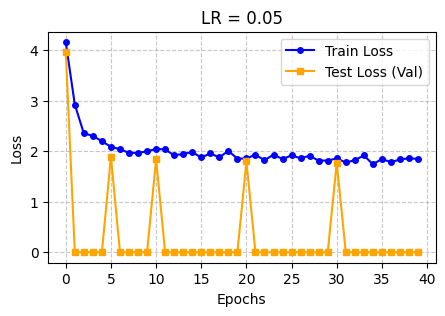

<Axes: title={'center': 'LR = 0.05'}, xlabel='Epochs', ylabel='Loss'>

In [ ]:
import matplotlib.pyplot as plt
from cellpose import train, models, io

X_train,Y_train = visualizer.load_set(ids_train)
X_val,Y_val   = visualizer.load_set(ids_val)

io.logger_setup()
model_finetune = models.CellposeModel(gpu=True)

model_path, t_loss, v_loss = train.train_seg(
    model_finetune.net,
    train_data=X_train,
    train_labels=Y_train,
    test_data=X_val,
    test_labels=Y_val,
    n_epochs=40,          
    learning_rate= 1e-5,
    weight_decay=0.0001,  
    save_path='.',
    model_name='cyto4_100'
)

print(f"Modèle sauvegardé : {model_path}")

visualizer.plot_loss(t_loss, v_loss, title=f"LR = {0.05}",show=True)


2026-04-01 12:59:02,450 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-04-01 12:59:02,450 [INFO] 
cellpose version: 	4.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-04-01 12:59:02,452 [INFO] ** TORCH CUDA version installed and working. **
2026-04-01 12:59:02,452 [INFO] >>>> using GPU (CUDA)
2026-04-01 12:59:04,576 [INFO] >>>> loading model ./models/cyto4_50.pth
Début du traitement, de l'évaluation et de l'export des visualisations (planche 4 images)...

RESULTATS GLOBAUX : Cellpose4 cell
Images evaluees          : 10
Total Vrais Positifs (TP): 263
Total Faux Positifs (FP) : 51
Total Faux Negatifs (FN) : 26
--------------------------------------------------
F1-Score Global (Micro)  : 0.872
F1-Score Moyen (Macro)   : 0.876



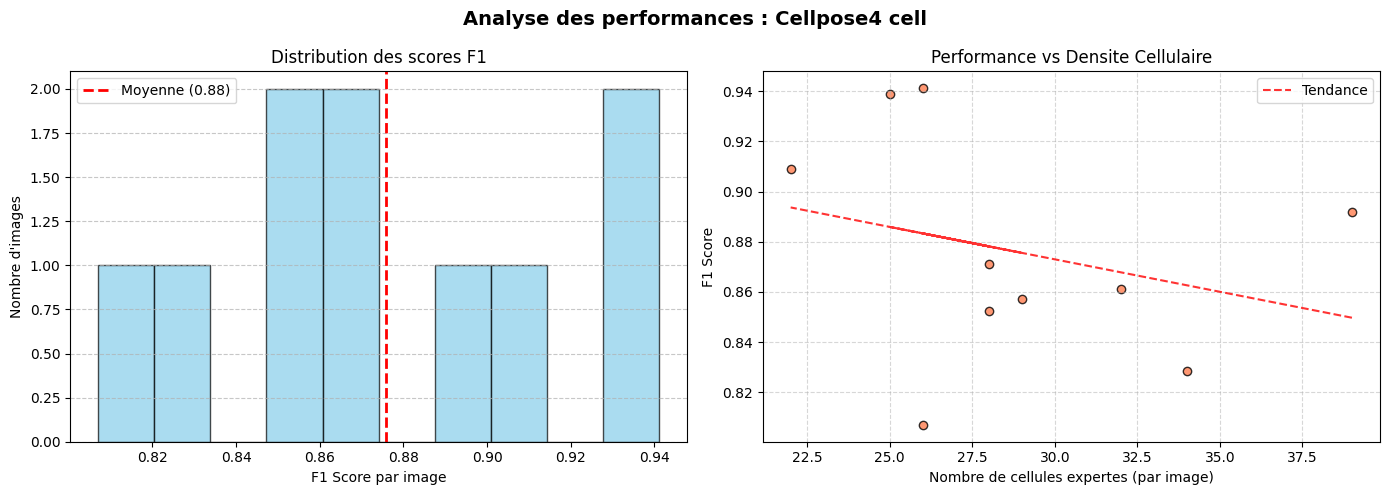

In [12]:
io.logger_setup()
model = models.CellposeModel(gpu=True, pretrained_model='./models/cyto4_50.pth')

base_output = './data/prediction/cellpose4_cyto/'
output_dir_masks = os.path.join(base_output, 'masks/')
output_dir_viz = os.path.join(base_output, 'visualizations/')

os.makedirs(output_dir_masks, exist_ok=True)
os.makedirs(output_dir_viz, exist_ok=True)

ev = tool.Stats()
all_results = [] 

print("Début du traitement, de l'évaluation et de l'export des visualisations (planche 4 images)...")

for img_id in ids_val:
    img = visualizer.load_data(img_id, mode='Image')
    true_mask = visualizer.load_data(img_id, mode='Cell')
    
    masks, flows, styles = model.eval(img, resample=True,flow_threshold=0.4, cellprob_threshold=0.0)
    
    save_path_mask = os.path.join(output_dir_masks, f"{img_id}_Cell_pred.bmp")
    cv2.imwrite(save_path_mask, masks.astype(np.uint16)) 
    

    all_results.append(ev.report("Cellpose4_cyto", true_mask, masks, show=False))
    perf = ev.summary_perf(true_mask, masks, iou_threshold=0.5)
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 20))
    ax1, ax2, ax3, ax4 = axes.flatten()
    
    visualizer.plot(i=img_id, mode='Image', ax=ax1, show=False)
    ax1.set_title("A. Image Brute")

    visualizer.plot_overlay(i=img_id, mask_pred=masks, ax=ax2, show=False, mode='Cell')
    ax2.set_title("B. Superposition ( vert expert, rouge cellpose)")
    
    visualizer.plot(i=img_id, mode='Cell', ax=ax3, show=False)
    ax3.set_title("C. Masque Expert")
    
    visualizer.plot(data=masks, mode='Cell_pred', ax=ax4, show=False)
    ax4.set_title("D. Prédiction Cellpose ")
    
    titre_rapport = (f"Rapport Image : {img_id} | "
                     f"F1-Score: {perf['f1']:.3f} | "
                     f"TP : {perf['tp']} , FP : {perf['fp']} , FN : {perf['fn']}")
    
    fig.suptitle(titre_rapport, fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.85)
    
    save_path_viz = os.path.join(output_dir_viz, f"{img_id}_rapport_complet.png")
    plt.savefig(save_path_viz, dpi=150, bbox_inches='tight')
    
    plt.close(fig)

df_final = ev.global_report(all_results, model_name=f"Cellpose4 cell")

In [13]:
oc.download_path('/content/data/prediction/cellpose4_cyto/','/travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_cyto')

Dossier cellpose4_cyto envoyé vers /travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_cyto.zip


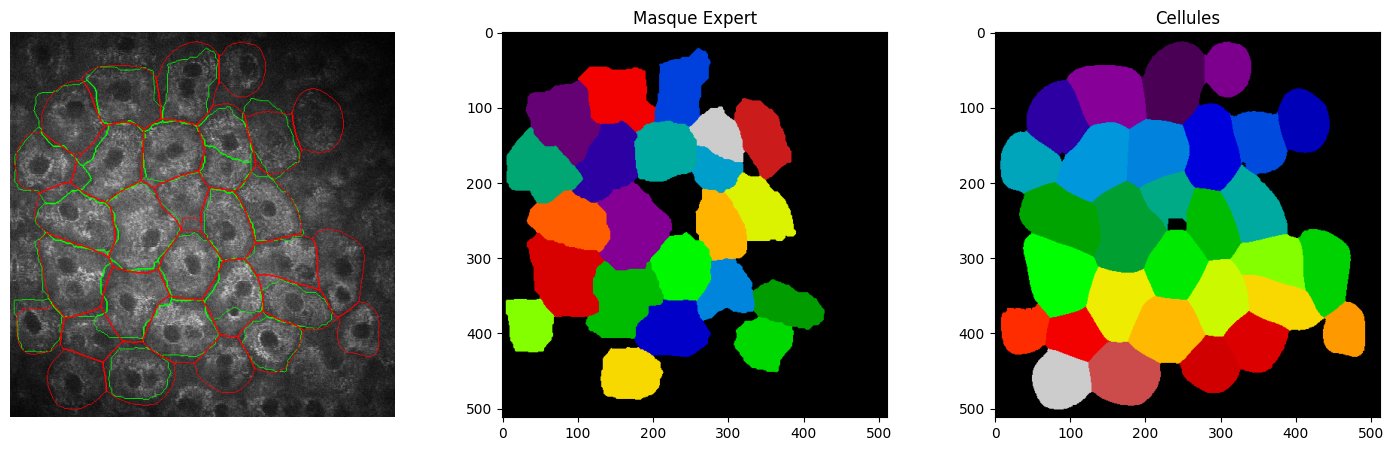

In [ ]:
img_id = '065'
img = visualizer.load_data(img_id, mode='Image')
true_mask = visualizer.load_data(img_id, mode='Cell')
masks, flows, styles = model.eval(img, resample=True)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
visualizer.plot_overlay(i=img_id, mask_pred=masks, ax=ax1, show=False)
visualizer.plot(data=masks, mode='Cell_pred', ax=ax3, show=False)
visualizer.plot(i=img_id, mode='Cell', ax=ax2, show=False, title="Masque Expert")
plt.show()

In [ ]:
io.logger_setup()
model = models.CellposeModel(gpu=True, pretrained_model='./models/cyto4_50.pth')

base_output = './data/prediction/cellpose4_50/'
output_dir_masks = os.path.join(base_output, 'masks/')
output_dir_viz = os.path.join(base_output, 'visualizations/')

os.makedirs(output_dir_masks, exist_ok=True)
os.makedirs(output_dir_viz, exist_ok=True)

ev = tool.Stats()
all_results = [] 

print("Début du traitement, de l'évaluation et de l'export des visualisations (planche 4 images)...")

for img_id in ids_val:
    img = visualizer.load_data(img_id, mode='Image')
    true_mask = visualizer.load_data(img_id, mode='Cell')
    
    masks, flows, styles = model.eval(img, resample=True)
    
    save_path_mask = os.path.join(output_dir_masks, f"{img_id}_Cell_pred.bmp")
    cv2.imwrite(save_path_mask, masks.astype(np.uint16)) 
    

    all_results.append(ev.report("Cellpose4_50", true_mask, masks, show=False))
    perf = ev.summary_perf(true_mask, masks, iou_threshold=0.5)
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 20))
    ax1, ax2, ax3, ax4 = axes.flatten()
    
    visualizer.plot(i=img_id, mode='Image', ax=ax1, show=False)
    ax1.set_title("A. Image Brute")

    visualizer.plot_overlay(i=img_id, mask_pred=masks, ax=ax4, show=False)
    ax4.set_title("B. Superposition")
    
    visualizer.plot(i=img_id, mode='Cell', ax=ax2, show=False)
    ax2.set_title("C. Masque Expert")
    
    visualizer.plot(data=masks, mode='Cell_pred', ax=ax3, show=False)
    ax3.set_title("D. Prédiction Cellpose ( vert expert, rouge cellpose)")
    
    titre_rapport = (f"Rapport Image : {img_id} | "
                     f"F1-Score: {perf['f1']:.3f} | "
                     f"TP : {perf['tp']} , FP : {perf['fp']} , FN : {perf['fn']}")
    
    fig.suptitle(titre_rapport, fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.85)
    
    save_path_viz = os.path.join(output_dir_viz, f"{img_id}_rapport_complet.png")
    plt.savefig(save_path_viz, dpi=150, bbox_inches='tight')
    
    plt.close(fig)

creating new log file
2026-03-26 09:34:54,060 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-26 09:34:54,062 [INFO] 
cellpose version: 	4.1.0 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-03-26 09:34:54,523 [INFO] ** TORCH CUDA version installed and working. **
2026-03-26 09:34:54,525 [INFO] >>>> using GPU (CUDA)
2026-03-26 09:34:57,065 [INFO] >>>> loading model ./models/cyto4_50.pth
Début du traitement, de l'évaluation et de l'export des visualisations (planche 4 images)...


In [ ]:
oc.download_path('/content/data/prediction/cellpose4_50/','/travail/Mines/DIMA/Segmentation/data/prediction/DIMA_cellposeSAM_val')

Dossier cellpose4_50 envoyé vers /travail/Mines/DIMA/Segmentation/data/prediction/DIMA_cellposeSAM_val.zip


In [ ]:
import matplotlib.pyplot as plt
from cellpose import train, models, io

# Définition des modes à évaluer
modes_experimentaux = ['Nuc_Pred']

io.logger_setup()

for mode_actuel in modes_experimentaux:
    
    print(f"--- ENTRAÎNEMENT : MODE {mode_actuel} ---")

    X_train, Y_train = visualizer.load_channel(ids_train, mode=mode_actuel)
    X_val, Y_val     = visualizer.load_set(ids_val, mode='Cell')

    nom_modele = f'cyto4_40_{mode_actuel.lower()}'

    # 3. Entraînement
    model_finetune = models.CellposeModel(gpu=True)

    model_path, t_loss, v_loss = train.train_seg(
        model_finetune.net,
        train_data=X_train,
        train_labels=Y_train,
        test_data=X_val,
        test_labels=Y_val,
        n_epochs=40,          
        learning_rate= 1e-5,
        weight_decay=0.0001,  
        save_path='.',
        model_name=nom_modele
    )

    print(f"Modèle {mode_actuel} sauvegardé avec succès : {model_path}")

    oc.oc.put_file(
        f'/travail/Mines/DIMA/Segmentation/results/models/{nom_modele}.pth',
        model_path, timeout=900
    )

    titre_graphique = f"Courbe de Perte - Mode {mode_actuel.upper()} (LR = 0.05)"
    visualizer.plot_loss(t_loss, v_loss, title=titre_graphique, show=True)

print("\nProcessus de benchmarking terminé pour les trois modes.")

2026-03-30 09:33:03,752 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-30 09:33:03,752 [INFO] 
cellpose version: 	4.1.0 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128


--- ENTRAÎNEMENT : MODE Nuc_Pred ---
2026-03-30 09:33:06,304 [INFO] ** TORCH CUDA version installed and working. **
2026-03-30 09:33:06,305 [INFO] >>>> using GPU (CUDA)
2026-03-30 09:33:08,523 [INFO] >>>> loading model /root/.cellpose/models/cpsam
2026-03-30 09:33:09,404 [INFO] >>> converting bfloat16 network to float32 for training
2026-03-30 09:33:09,414 [INFO] computing flows for labels


100%|██████████| 71/71 [00:07<00:00,  9.56it/s]

2026-03-30 09:33:16,882 [INFO] computing flows for labels



100%|██████████| 10/10 [00:01<00:00,  9.90it/s]

2026-03-30 09:33:17,900 [INFO] >>> computing diameters



100%|██████████| 10/10 [00:00<00:00, 812.57it/s]

2026-03-30 09:33:18,003 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-03-30 09:33:18,748 [INFO] >>> n_epochs=40, n_train=71, n_test=10
2026-03-30 09:33:18,748 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-03-30 09:33:18,751 [INFO] >>> saving model to models/cyto4_40_nuc_pred
2026-03-30 09:33:46,585 [INFO] 0, train_loss=3.9290, test_loss=3.9966, LR=0.000000, time 27.84s
2026-03-30 09:36:03,442 [INFO] 5, train_loss=2.4003, test_loss=2.1729, LR=0.000006, time 164.69s
2026-03-30 09:38:20,638 [INFO] 10, train_loss=1.9756, test_loss=1.8938, LR=0.000010, time 301.89s
2026-03-30 09:42:53,897 [INFO] 20, train_loss=1.9212, test_loss=1.9897, LR=0.000010, time 575.15s
2026-03-30 09:47:27,110 [INFO] 30, train_loss=1.8620, test_loss=1.8809, LR=0.000010, time 848.36s
2026-03-30 09:51:32,118 [INFO] saving network parameters to models/cyto4_40_nuc_pred
2026-03-30 09:51:43,916 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle Nuc_Pred sauvegardé avec succès : models/cyto4_40_nuc_pred


HTTPResponseError: HTTP error: 504

In [ ]:
oc.oc.put_file(
    '/travail/Mines/DIMA/Segmentation/results/models/cyto4_raw_40.pth',
    'models/cyto4_40_raw', timeout=600                                  
)

HTTPResponseError: HTTP error: 504

2026-03-30 09:59:58,534 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-30 09:59:58,535 [INFO] 
cellpose version: 	4.1.0 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128

--- EVAL : MODE cyto4_40_clahe ---
Chargement du modèle depuis : ./models/cyto4_40_clahe
2026-03-30 09:59:58,537 [INFO] ** TORCH CUDA version installed and working. **
2026-03-30 09:59:58,538 [INFO] >>>> using GPU (CUDA)
2026-03-30 10:00:00,738 [INFO] >>>> loading model ./models/cyto4_40_clahe
2026-03-30 10:00:01,730 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-03-30 10:00:05,930 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-03-30 10:00:09,396 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-03-30 10:00:12,920 [WARNING] channels deprecated in v4.

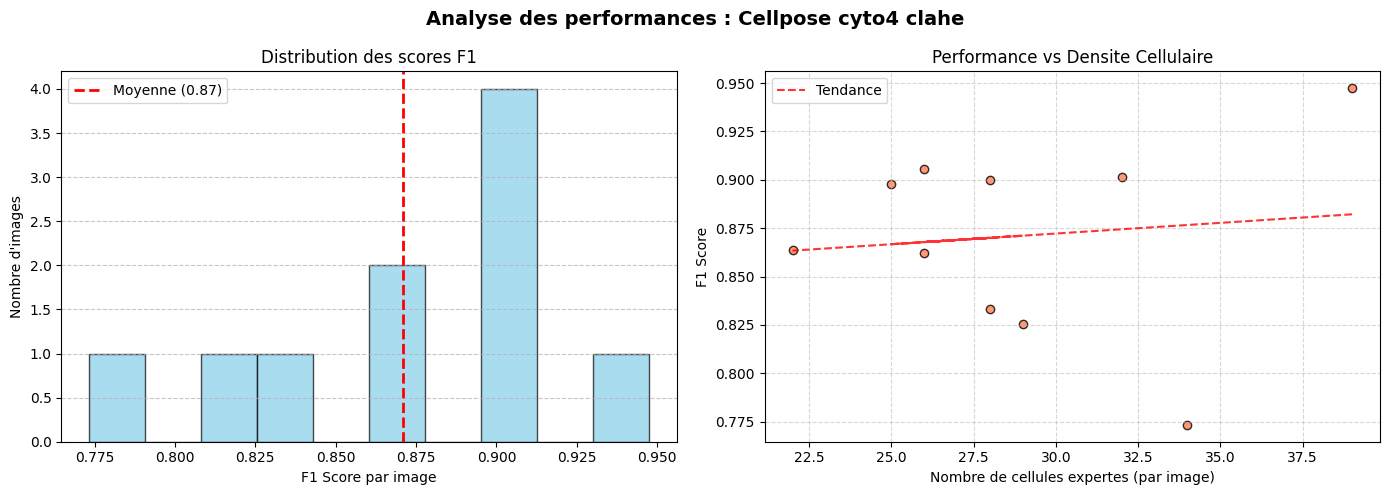

Dossier cellpose4_clahe envoyé vers /travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_clahe.zip

--- EVAL : MODE cyto4_40_nuc_pred ---
Chargement du modèle depuis : ./models/cyto4_40_nuc_pred
2026-03-30 10:00:48,414 [INFO] ** TORCH CUDA version installed and working. **
2026-03-30 10:00:48,415 [INFO] >>>> using GPU (CUDA)
2026-03-30 10:00:50,491 [INFO] >>>> loading model ./models/cyto4_40_nuc_pred
2026-03-30 10:00:51,786 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-03-30 10:00:55,466 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-03-30 10:00:59,045 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-03-30 10:01:02,681 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-03-30 10:01:0

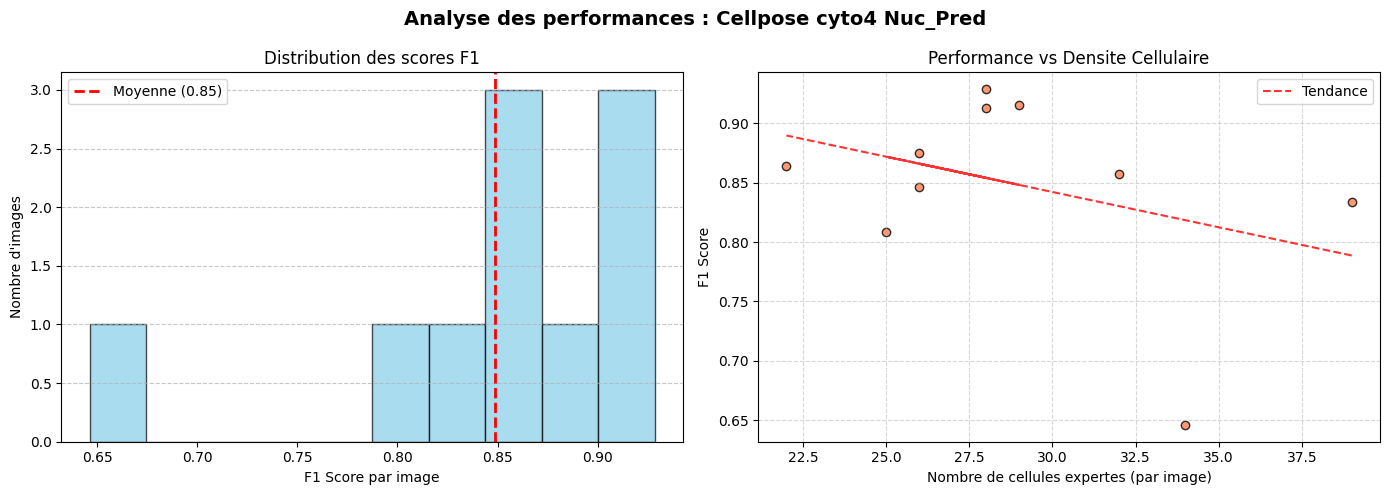

Dossier cellpose4_nuc_pred envoyé vers /travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_nuc_pred.zip

Évaluation terminée. Vous pouvez maintenant afficher le DataFrame all_results.


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models, io

io.logger_setup()
ev = tool.Stats()
# modes_experimentaux = ['raw', 'clahe', 'Nuc_Pred']
modes_experimentaux = ['clahe', 'Nuc_Pred']
for mode_actuel in modes_experimentaux:
    all_results = [] 
    nom_modele = f'cyto4_40_{mode_actuel.lower()}'
    print(f"\n--- EVAL : MODE {nom_modele} ---")

    chemin_modele = f'./models/{nom_modele}'
    print(f"Chargement du modèle depuis : {chemin_modele}")
    model = models.CellposeModel(gpu=True, pretrained_model=chemin_modele)

    base_output = f'./data/prediction/cellpose4_{mode_actuel.lower()}/'
    output_dir_masks = os.path.join(base_output, 'masks/')
    output_dir_viz = os.path.join(base_output, 'visualizations/')

    os.makedirs(output_dir_masks, exist_ok=True)
    os.makedirs(output_dir_viz, exist_ok=True)

    X_val_multi, Y_val_true = visualizer.load_channel(ids_val, mode=mode_actuel)

    for idx, img_id in enumerate(ids_val):
        img_stack = X_val_multi[idx]
        true_mask = Y_val_true[idx]
        
        masks, flows, styles = model.eval(
            img_stack, 
            channels=[1, 2], 
            resample=True, 
            flow_threshold=0.4, 
            cellprob_threshold=0.0
        )
        
        save_path_mask = os.path.join(output_dir_masks, f"{img_id}_Cell_pred.bmp")
        cv2.imwrite(save_path_mask, masks.astype(np.uint16)) 
        
        # CORRECTION : Rapport dynamique
        nom_rapport = f"Cellpose_cyto4_{mode_actuel}"
        all_results.append(ev.report(nom_rapport, true_mask, masks, show=False))
        perf = ev.summary_perf(true_mask, masks, iou_threshold=0.5)
        
        fig, axes = plt.subplots(2, 2, figsize=(20, 20))
        ax1, ax2, ax3, ax4 = axes.flatten()
        
        visualizer.plot(i=img_id, mode='Image', ax=ax1, show=False)
        ax1.set_title("A. Image Brute")

        visualizer.plot_overlay(i=img_id, mask_pred=masks, ax=ax2, show=False, mode='Cell')
        ax2.set_title("B. Superposition (vert expert, rouge cellpose)")
        
        visualizer.plot(i=img_id, mode='Cell', ax=ax4, show=False)
        ax4.set_title("C. Masque Expert")
        
        visualizer.plot(data=masks, mode='Cell_pred', ax=ax3, show=False)
        ax3.set_title("D. Prédiction Cellpose")
        
        titre_rapport = (f"Rapport Image : {img_id} (Mode : {mode_actuel.upper()}) | "
                        f"F1-Score: {perf['f1']:.3f} | "
                        f"TP : {perf['tp']} , FP : {perf['fp']} , FN : {perf['fn']}")
        
        fig.suptitle(titre_rapport, fontsize=16, fontweight='bold', y=0.98)
        
        plt.tight_layout()
        fig.subplots_adjust(top=0.85)
        
        save_path_viz = os.path.join(output_dir_viz, f"{img_id}_cell_pred_viz.png")
        plt.savefig(save_path_viz, dpi=150, bbox_inches='tight')
        plt.close(fig)
    df_final = ev.global_report(all_results, model_name=f"Cellpose cyto4 {mode_actuel}")
    oc.download_path(base_output,f'/travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_{mode_actuel.lower()}')


print("\nÉvaluation terminée. Vous pouvez maintenant afficher le DataFrame all_results.")

In [ ]:
oc.download_path('/content/data/prediction/cellpose4_raw/','/travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_raw')

Dossier cellpose4_raw envoyé vers /travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_raw.zip


creating new log file
2026-03-31 08:45:23,369 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-31 08:45:23,369 [INFO] 
cellpose version: 	4.1.1.dev3+ga9f8bfcde 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-03-31 08:45:23,370 [INFO] ** TORCH CUDA version installed and working. **
2026-03-31 08:45:23,371 [INFO] >>>> using GPU (CUDA)
2026-03-31 08:45:25,852 [INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpsam" to /root/.cellpose/models/cpsam



100%|██████████| 1.15G/1.15G [00:04<00:00, 274MB/s]


2026-03-31 08:45:31,692 [INFO] >>> converting bfloat16 network to float32 for training
2026-03-31 08:45:31,702 [INFO] computing flows for labels


100%|██████████| 71/71 [00:02<00:00, 30.18it/s]

2026-03-31 08:45:34,083 [INFO] computing flows for labels



100%|██████████| 10/10 [00:00<00:00, 34.14it/s]

2026-03-31 08:45:34,383 [INFO] >>> computing diameters



100%|██████████| 10/10 [00:00<00:00, 761.23it/s]

2026-03-31 08:45:34,494 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-03-31 08:45:35,002 [INFO] >>> n_epochs=40, n_train=71, n_test=10
2026-03-31 08:45:35,002 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-03-31 08:45:35,004 [INFO] >>> saving model to models/cellpose4_nuclei
2026-03-31 08:46:04,398 [INFO] 0, train_loss=1.7694, test_loss=1.5357, LR=0.000000, time 29.39s
2026-03-31 08:48:21,543 [INFO] 5, train_loss=0.3692, test_loss=0.1694, LR=0.000006, time 166.54s
2026-03-31 08:50:39,672 [INFO] 10, train_loss=0.1884, test_loss=0.1544, LR=0.000010, time 304.67s
2026-03-31 08:55:14,889 [INFO] 20, train_loss=0.1814, test_loss=0.1491, LR=0.000010, time 579.88s
2026-03-31 08:59:50,026 [INFO] 30, train_loss=0.1707, test_loss=0.1431, LR=0.000010, time 855.02s
2026-03-31 09:03:56,653 [INFO] saving network parameters to models/cellpose4_nuclei
2026-03-31 09:04:04,564 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle sauvegardé : models/cellpose4_nuclei


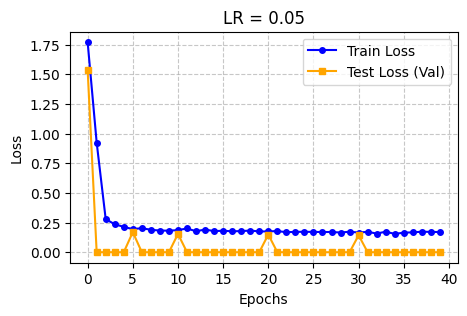

<Axes: title={'center': 'LR = 0.05'}, xlabel='Epochs', ylabel='Loss'>

In [8]:
import matplotlib.pyplot as plt
from cellpose import train, models, io

X_train,Y_train = visualizer.load_set(ids_train, mode='Nuc')
X_val,Y_val   = visualizer.load_set(ids_val, mode='Nuc')

io.logger_setup()
model_finetune = models.CellposeModel(gpu=True)

model_path, t_loss, v_loss = train.train_seg(
    model_finetune.net,
    train_data=X_train,
    train_labels=Y_train,
    test_data=X_val,
    test_labels=Y_val,
    n_epochs=40,          
    learning_rate= 1e-5,
    weight_decay=0.0001,  
    save_path='.',
    model_name='cellpose4_nuclei'
)

print(f"Modèle sauvegardé : {model_path}")

visualizer.plot_loss(t_loss, v_loss, title=f"LR = {0.05}",show=True)


In [ ]:
oc.oc.put_file(
    '/travail/Mines/DIMA/Segmentation/results/models/cellpose4_nuclei.pth',
    'models/cellpose4_nuclei', timeout=600                                  
)

2026-03-31 10:14:05,955 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-31 10:14:05,955 [INFO] 
cellpose version: 	4.1.1.dev3+ga9f8bfcde 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-03-31 10:14:05,956 [INFO] ** TORCH CUDA version installed and working. **
2026-03-31 10:14:05,957 [INFO] >>>> using GPU (CUDA)
2026-03-31 10:14:07,944 [INFO] >>>> loading model ./models/cellpose4_nuclei.pth
Début du traitement, de l'évaluation et de l'export des visualisations (planche 4 images)...

RESULTATS GLOBAUX : Cellpose4 nuclei ct_-0.5
Images evaluees          : 10
Total Vrais Positifs (TP): 304
Total Faux Positifs (FP) : 124
Total Faux Negatifs (FN) : 29
--------------------------------------------------
F1-Score Global (Micro)  : 0.799
F1-Score Moyen (Macro)   : 0.799



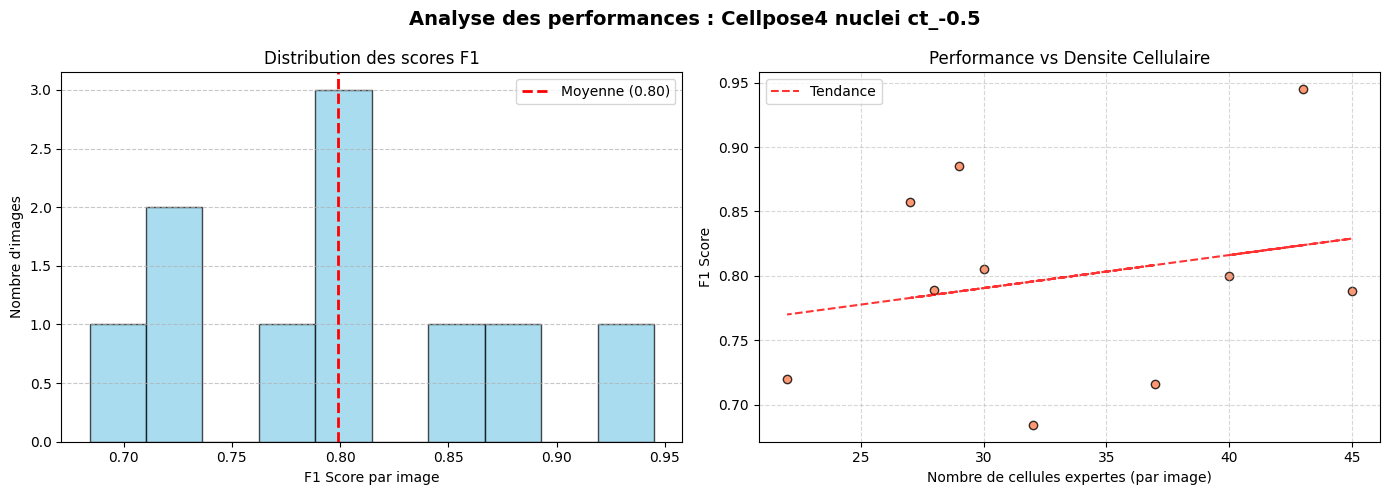

In [13]:
io.logger_setup()
model = models.CellposeModel(gpu=True, pretrained_model= './models/cellpose4_nuclei.pth')

base_output = './data/prediction/cellpose4_nuclei_ct_-0.5/'
output_dir_masks = os.path.join(base_output, 'masks/')
output_dir_viz = os.path.join(base_output, 'visualizations/')

os.makedirs(output_dir_masks, exist_ok=True)
os.makedirs(output_dir_viz, exist_ok=True)

ev = tool.Stats()
all_results = [] 

print("Début du traitement, de l'évaluation et de l'export des visualisations (planche 4 images)...")

for img_id in ids_val:
    img = visualizer.load_data(img_id, mode='Image')
    true_mask = visualizer.load_data(img_id, mode='Nuc')
    
    masks, flows, styles = model.eval(img, resample=True,flow_threshold=0.4, cellprob_threshold=-0.5)
    
    save_path_mask = os.path.join(output_dir_masks, f"{img_id}_Nuc_pred.bmp")
    cv2.imwrite(save_path_mask, masks.astype(np.uint16)) 
    

    all_results.append(ev.report("Cellpose4_nuclei_ct_-0.5", true_mask, masks, show=False))
    perf = ev.summary_perf(true_mask, masks, iou_threshold=0.5)
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 20))
    ax1, ax2, ax3, ax4 = axes.flatten()
    
    visualizer.plot(i=img_id, mode='Image', ax=ax1, show=False)
    ax1.set_title("A. Image Brute")

    visualizer.plot_overlay(i=img_id, mask_pred=masks, ax=ax2, show=False, mode='Nuc')
    ax2.set_title("B. Superposition ( vert expert, rouge cellpose)")
    
    visualizer.plot(i=img_id, mode='Nuc', ax=ax3, show=False)
    ax3.set_title("C. Masque Expert")
    
    visualizer.plot(data=masks, mode='Nuc_pred', ax=ax4, show=False)
    ax4.set_title("D. Prédiction Cellpose ")
    
    titre_rapport = (f"Rapport Image : {img_id} | "
                     f"F1-Score: {perf['f1']:.3f} | "
                     f"TP : {perf['tp']} , FP : {perf['fp']} , FN : {perf['fn']}")
    
    fig.suptitle(titre_rapport, fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.85)
    
    save_path_viz = os.path.join(output_dir_viz, f"{img_id}_rapport_complet.png")
    plt.savefig(save_path_viz, dpi=150, bbox_inches='tight')
    
    plt.close(fig)

df_final = ev.global_report(all_results, model_name=f"Cellpose4 nuclei ct_-0.5")

In [14]:
oc.download_path('/content/data/prediction/cellpose4_nuclei_ct_-0.5','/travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_nuclei_ct_-0.5')

Dossier cellpose4_nuclei_ct_-0.5 envoyé vers /travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_nuclei_ct_-0.5.zip
